# Dataset Visualization

Qualitative check of synthetic and GiftEval-wrapped examples with their labels.

**Layout per example:**
- Blue region = context (first 32 patches × 16 = 512 time steps)
- Orange region = prediction (last 4 patches × 16 = 64 time steps)
- Dashed black line = true or estimated trend
- Vertical grey lines = dominant period ticks

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'mech_interp'))
sys.path.insert(0, os.getcwd())  # when running from experiments/mech_interp/

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lib import (
    generate_dataset,
    wrap_existing_dataset,
    load_gift_eval_series,
    DEFAULT_GENERATORS,
    TrendLabelGenerator,
    SeasonalLabelGenerator,
    NoiseVarLabelGenerator,
)
from lib.synthetic import PERIOD_BINS

plt.rcParams.update({'font.size': 8, 'axes.titlesize': 8})

In [2]:
# ── Shared constants ──────────────────────────────────────────────────────────
PATCH_SIZE      = 16
CONTEXT_PATCHES = 32
PRED_PATCHES    = 4
SERIES_LENGTH   = (CONTEXT_PATCHES + PRED_PATCHES) * PATCH_SIZE  # 576
CONTEXT_END     = CONTEXT_PATCHES * PATCH_SIZE                    # 512

GIFT_EVAL_PATH  = '/srv/disk00/ctadler/uni2ts/datasets/giftevaltest'

N_COLS = 4
N_ROWS = 3
N_SHOW = N_COLS * N_ROWS  # 12 examples per section

In [3]:
def plot_example(ax, series, slope, period_idx, phase_cos, phase_sin, log_noise_var,
                 title_prefix='', estimated=False):
    """
    Plot a single example on `ax`.
    - Blue shading  = context window.
    - Red shading   = prediction window.
    - Dashed line   = trend.
    - Grey verticals = period ticks.
    """
    t = np.arange(SERIES_LENGTH)

    ax.axvspan(0, CONTEXT_END, alpha=0.07, color='steelblue', lw=0)
    ax.axvspan(CONTEXT_END, SERIES_LENGTH, alpha=0.07, color='tomato', lw=0)
    ax.axvline(CONTEXT_END, color='gray', lw=0.8, ls='--')

    ax.plot(t, series, lw=0.8, color='steelblue', alpha=0.9)

    # Trend: slope on normalized t ∈ [0,1]; intercept passes through series mean
    t_norm = t / SERIES_LENGTH
    intercept = series.mean() - slope * 0.5
    ax.plot(t, slope * t_norm + intercept, 'k--', lw=0.9, alpha=0.7)

    # Period ticks
    period_patches = PERIOD_BINS[int(period_idx)]
    period_ts = period_patches 
    for tick in range(0, SERIES_LENGTH, period_ts):
        ax.axvline(tick, color='gray', lw=0.5, alpha=0.4)

    phase_deg = np.degrees(np.arctan2(float(phase_sin), float(phase_cos)))
    tag = 'est' if estimated else 'gt'
    ax.set_title(
        f"{title_prefix}period={period_patches}p  slope={slope:.3f}\n"
        f"phase={phase_deg:.0f}\u00b0  log_\u03c3\u00b2={log_noise_var:.2f}  [{tag}]",
        pad=2,
    )
    ax.set_xlim(0, SERIES_LENGTH - 1)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('time step', fontsize=6)

---
## 1  Synthetic Dataset

Ground-truth labels. First row shows one example per period class ({8, 16, 32, 64} patches).

In [4]:
synth = generate_dataset(n=200, seed=42, patch_size=PATCH_SIZE,
                         context_patches=CONTEXT_PATCHES, pred_patches=PRED_PATCHES)
print('Keys:', list(synth.keys()))
print('series shape:', synth['series'].shape)
print('period_idx distribution:', dict(zip(*np.unique(synth['period_idx'], return_counts=True))))

Keys: ['series', 'slope', 'period_idx', 'phase_cos', 'phase_sin', 'log_noise_var']
series shape: (200, 576)
period_idx distribution: {0: 28, 1: 27, 2: 21, 3: 21, 4: 24, 5: 20, 6: 29, 7: 30}


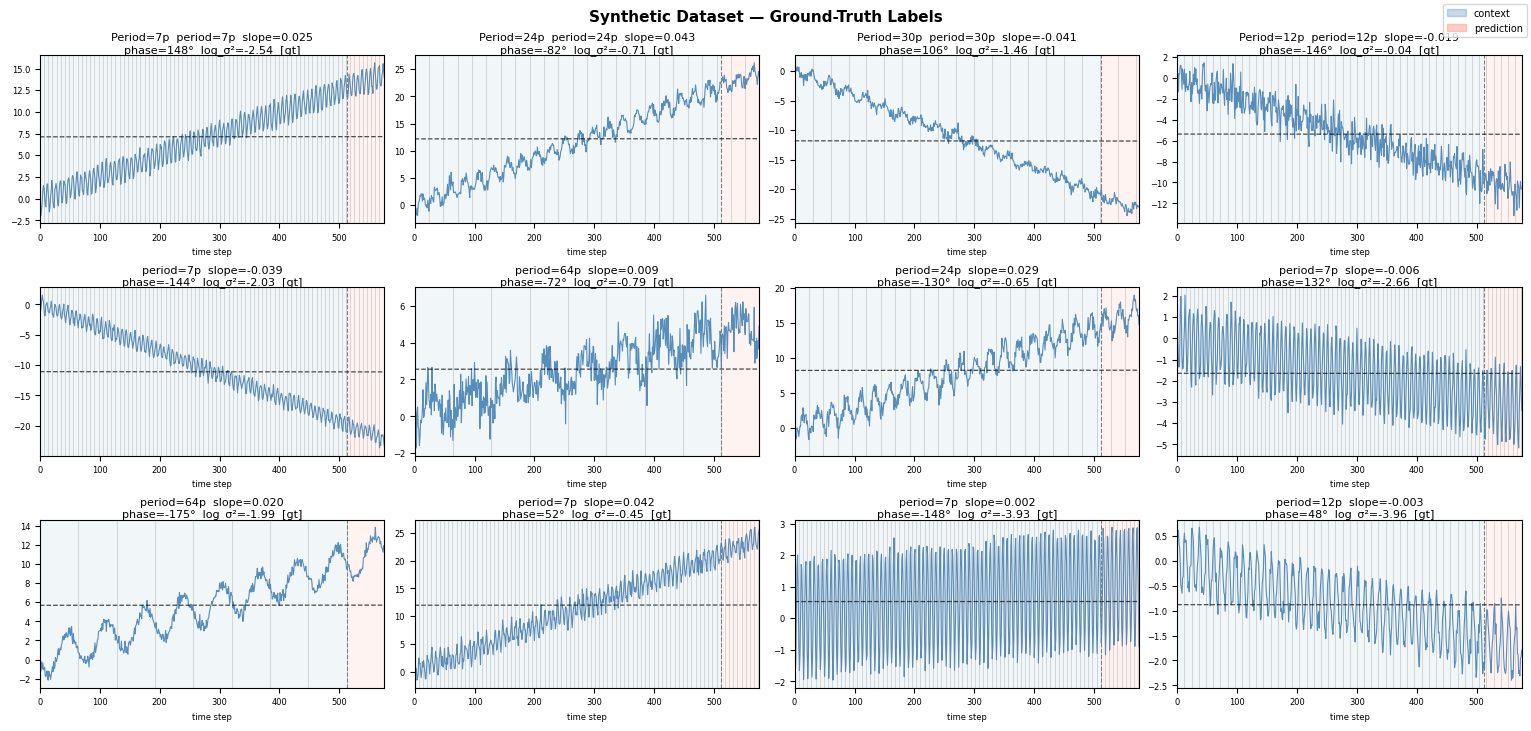

In [5]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3.8, N_ROWS * 2.4),
                         constrained_layout=True)
fig.suptitle('Synthetic Dataset — Ground-Truth Labels', fontsize=11, fontweight='bold')
fig.legend(handles=[
    mpatches.Patch(color='steelblue', alpha=0.3, label='context'),
    mpatches.Patch(color='tomato', alpha=0.3, label='prediction'),
], loc='upper right', fontsize=7)

rng = np.random.default_rng(0)

# First row: one example per period class
for pidx, ax in enumerate(axes[0]):
    candidates = np.where(synth['period_idx'] == pidx)[0]
    i = rng.choice(candidates)
    plot_example(ax, synth['series'][i], synth['slope'][i], synth['period_idx'][i],
                 synth['phase_cos'][i], synth['phase_sin'][i], synth['log_noise_var'][i],
                 title_prefix=f'Period={PERIOD_BINS[pidx]}p  ')

# Remaining rows: random
for ax, i in zip(axes[1:].flat,
                 rng.choice(len(synth['series']), size=N_COLS * (N_ROWS - 1), replace=False)):
    plot_example(ax, synth['series'][i], synth['slope'][i], synth['period_idx'][i],
                 synth['phase_cos'][i], synth['phase_sin'][i], synth['log_noise_var'][i])

plt.show()

### 1b  Label distributions (synthetic)

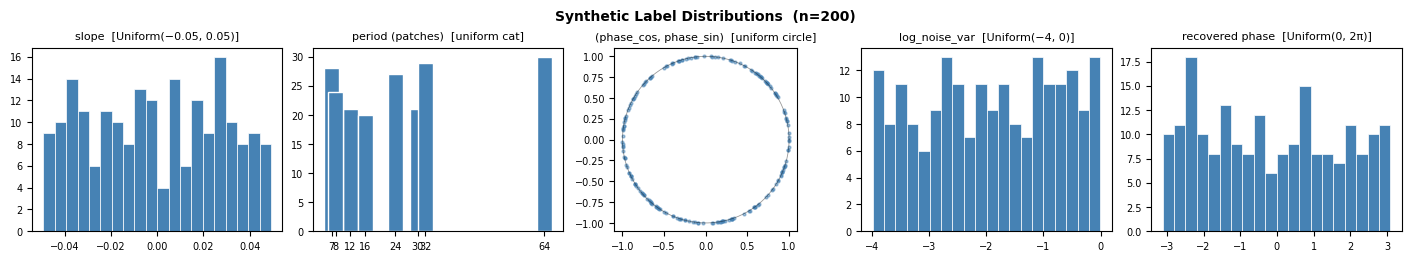

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.5), constrained_layout=True)
fig.suptitle('Synthetic Label Distributions  (n=200)', fontsize=10, fontweight='bold')

axes[0].hist(synth['slope'], bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[0].set_title('slope  [Uniform(−0.05, 0.05)]')

counts = np.bincount(synth['period_idx'], minlength=4)
axes[1].bar(PERIOD_BINS, counts, width=4, color='steelblue', edgecolor='white')
axes[1].set_title('period (patches)  [uniform cat]')
axes[1].set_xticks(PERIOD_BINS)

axes[2].scatter(synth['phase_cos'], synth['phase_sin'], s=4, alpha=0.5, color='steelblue')
theta = np.linspace(0, 2*np.pi, 200)
axes[2].plot(np.cos(theta), np.sin(theta), 'k-', lw=0.6, alpha=0.4)
axes[2].set_aspect('equal')
axes[2].set_title('(phase_cos, phase_sin)  [uniform circle]')

axes[3].hist(synth['log_noise_var'], bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[3].set_title('log_noise_var  [Uniform(−4, 0)]')

phases = np.arctan2(synth['phase_sin'], synth['phase_cos'])
axes[4].hist(phases, bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[4].set_title('recovered phase  [Uniform(0, 2\u03c0)]')

for ax in axes:
    ax.tick_params(labelsize=7)
plt.show()

---
## 2  Estimated Labels on Synthetic Series

Apply `DEFAULT_GENERATORS` to the same synthetic series (without ground-truth) to gauge estimation quality before using on real data.

In [8]:
# Apply generators directly to each synthetic series (no windowing needed — they are exactly SERIES_LENGTH)
trend_gen  = TrendLabelGenerator()
season_gen = SeasonalLabelGenerator()
noise_gen  = NoiseVarLabelGenerator()

est_slopes, est_period_idxs, est_log_noise = [], [], []
for s in synth['series']:
    est_slopes.append(float(trend_gen(s)['slope']))
    est_period_idxs.append(int(season_gen(s)['period_idx']))
    est_log_noise.append(float(noise_gen(s)['log_noise_var']))

est_slopes      = np.array(est_slopes)
est_period_idxs = np.array(est_period_idxs)
est_log_noise   = np.array(est_log_noise)

gt_slopes      = synth['slope']
gt_period_idxs = synth['period_idx']
gt_log_noise   = synth['log_noise_var']

period_accuracy = (est_period_idxs == gt_period_idxs).mean()
map_func =  np.vectorize(lambda x: PERIOD_BINS[x])
slope_corr      = float(np.corrcoef(gt_slopes, est_slopes)[0, 1])
noise_corr      = float(np.corrcoef(gt_log_noise, est_log_noise)[0, 1])

print(f'Period classification accuracy  : {period_accuracy:.1%}')
print(f'Slope correlation (GT vs est)   : {slope_corr:.3f}')
print(f'Log-noise correlation (GT vs est): {noise_corr:.3f}')

Period classification accuracy  : 26.0%
Slope correlation (GT vs est)   : 1.000
Log-noise correlation (GT vs est): 0.410


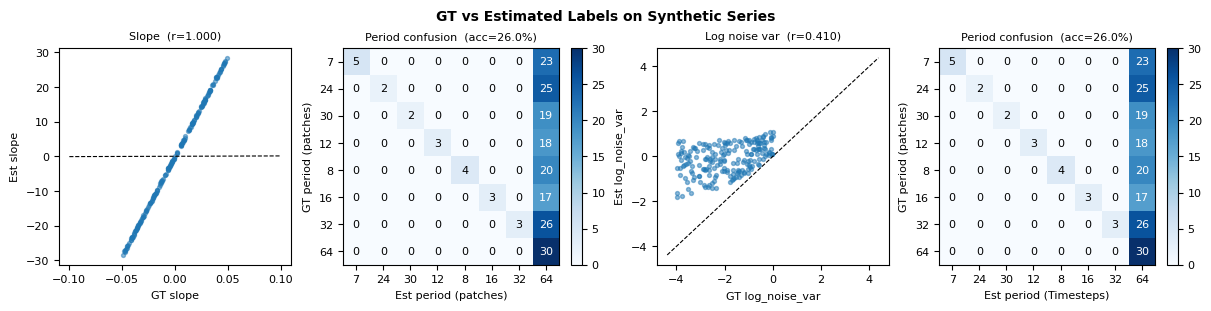

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
fig.suptitle('GT vs Estimated Labels on Synthetic Series', fontsize=10, fontweight='bold')

# Slope scatter
axes[0].scatter(gt_slopes, est_slopes, s=8, alpha=0.5)
# lim = max(abs(gt_slopes).max(), abs(est_slopes).max()) * 1.1
lim = 0.1
axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
axes[0].set_xlabel('GT slope'); axes[0].set_ylabel('Est slope')
axes[0].set_title(f'Slope  (r={slope_corr:.3f})')

# Period confusion matrix
cm = np.zeros((8, 8), dtype=int)
for gt, est in zip(gt_period_idxs, est_period_idxs):
    cm[int(gt), int(est)] += 1
im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(8)); axes[1].set_yticks(range(8))
axes[1].set_xticklabels(PERIOD_BINS); axes[1].set_yticklabels(PERIOD_BINS)
axes[1].set_xlabel('Est period (patches)'); axes[1].set_ylabel('GT period (patches)')
axes[1].set_title(f'Period confusion  (acc={period_accuracy:.1%})')
for gi in range(8):
    for ei in range(8):
        axes[1].text(ei, gi, str(cm[gi, ei]), ha='center', va='center', fontsize=8,
                     color='white' if cm[gi, ei] > cm.max() * 0.5 else 'black')
        
# Period confusion matrix
cm = np.zeros((8, 8), dtype=int)
for gt, est in zip(gt_period_idxs, est_period_idxs):
    cm[int(gt), int(est)] += 1
im = axes[3].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[3])
axes[3].set_xticks(range(8)); axes[3].set_yticks(range(8))
axes[3].set_xticklabels(PERIOD_BINS); axes[3].set_yticklabels(PERIOD_BINS)
axes[3].set_xlabel('Est period (Timesteps)'); axes[3].set_ylabel('GT period (patches)')
axes[3].set_title(f'Period confusion  (acc={period_accuracy:.1%})')
for gi in range(8):
    for ei in range(8):
        axes[3].text(ei, gi, str(cm[gi, ei]), ha='center', va='center', fontsize=8,
                     color='white' if cm[gi, ei] > cm.max() * 0.5 else 'black')

# Log-noise scatter
axes[2].scatter(gt_log_noise, est_log_noise, s=8, alpha=0.5)
lim = max(abs(gt_log_noise).max(), abs(est_log_noise).max()) * 1.1
axes[2].plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
axes[2].set_xlabel('GT log_noise_var'); axes[2].set_ylabel('Est log_noise_var')
axes[2].set_title(f'Log noise var  (r={noise_corr:.3f})')

plt.show()

---
## 3  GiftEval Dataset — Estimated Labels

Load a real dataset, sample windows, apply `DEFAULT_GENERATORS`, and visualize.

Change `GIFT_DATASET` to explore other datasets, e.g. `"m4_monthly"`, `"ett1/H"`, `"solar/H"`.

In [10]:
GIFT_DATASET = 'electricity/H'  # hourly electricity — rich daily/weekly periodicity

raw_series = load_gift_eval_series(GIFT_DATASET, storage_path=GIFT_EVAL_PATH)
eligible   = [s for s in raw_series if len(s) >= SERIES_LENGTH]
print(f'Dataset      : {GIFT_DATASET}')
print(f'Total series : {len(raw_series)}')
print(f'Eligible (len >= {SERIES_LENGTH}): {len(eligible)}')
print(f'Length range : {min(len(s) for s in eligible)} – {max(len(s) for s in eligible)}')

Dataset      : electricity/H
Total series : 370
Eligible (len >= 576): 370
Length range : 31557 – 31557


In [12]:
gift_data = wrap_existing_dataset(
    raw_series, DEFAULT_GENERATORS,
    series_length=SERIES_LENGTH, n=200, seed=42,
)
print('Keys:', list(gift_data.keys()))
print('series shape:', gift_data['series'].shape)
print('period_idx distribution:', dict(zip(*np.unique(gift_data['period_idx'], return_counts=True))))

Keys: ['series', 'slope', 'period_idx', 'phase_cos', 'phase_sin', 'log_noise_var']
series shape: (200, 576)
period_idx distribution: {0: 1, 1: 196, 7: 3}


0 135 7 1
1 95 24 196
2 102 30 0
3 151 12 0
4 190 8 0
5 6 16 0
6 28 32 0
7 84 64 3

135 0 7
95 1 24
102 1 24
151 1 24
190 1 24
6 1 24
28 1 24
84 7 64


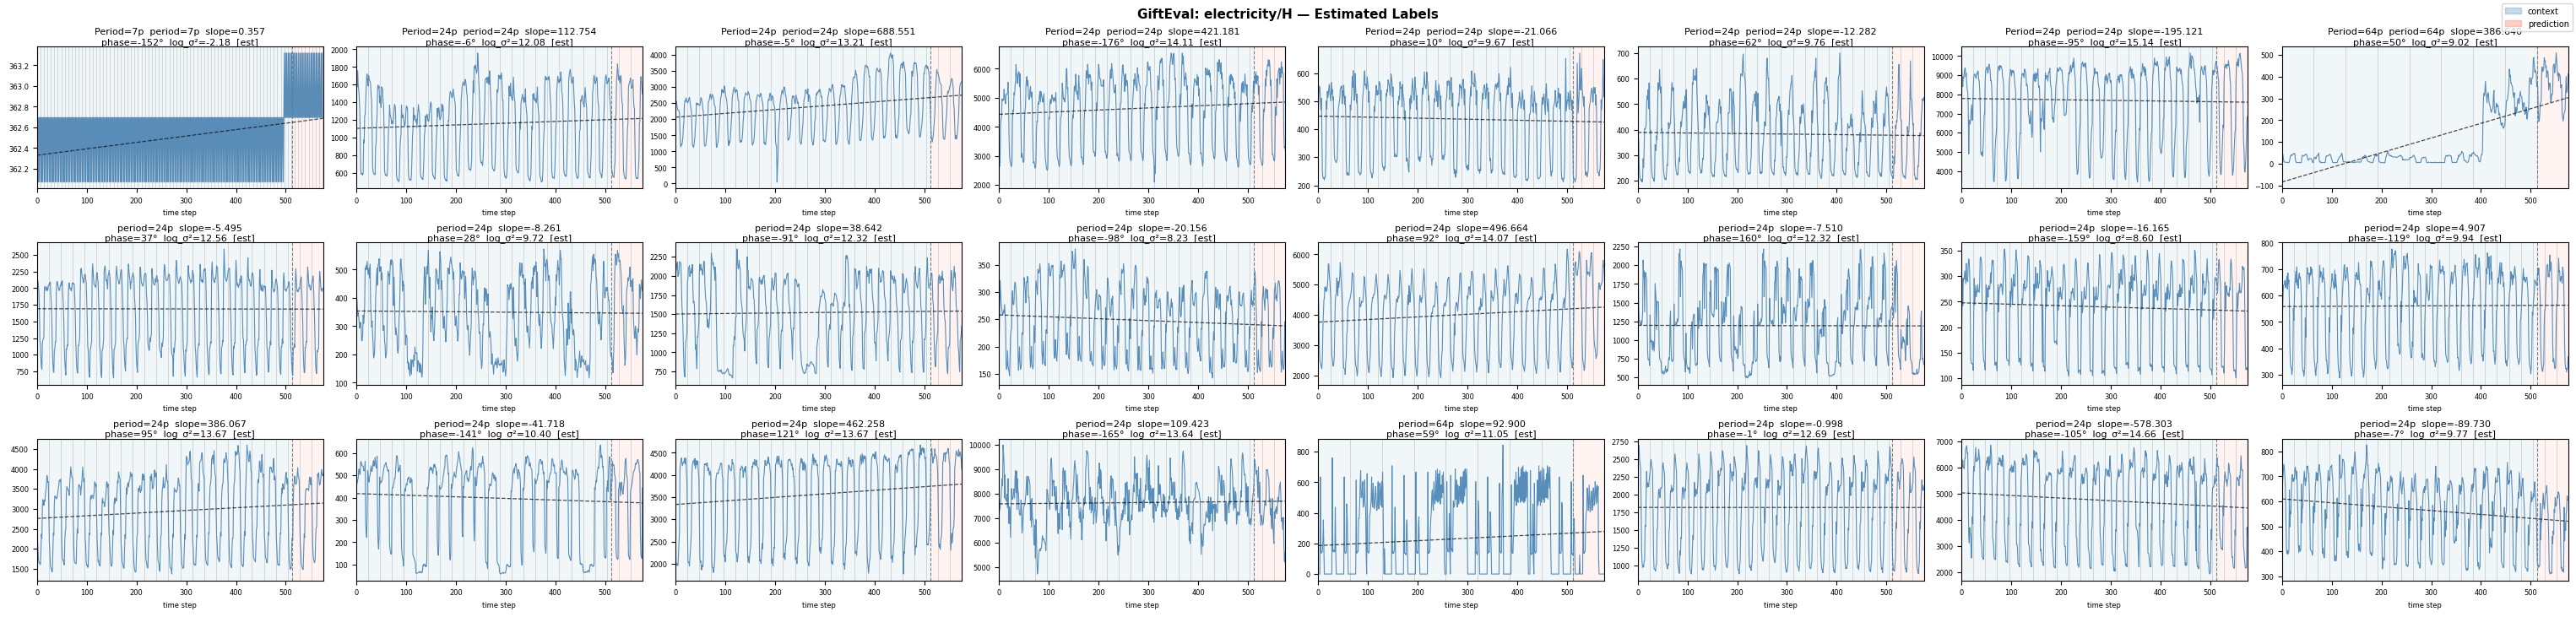

In [13]:
fig, axes = plt.subplots(N_ROWS, 8, figsize=(8 * 3.8, N_ROWS * 2.4),
                         constrained_layout=True)
fig.suptitle(f'GiftEval: {GIFT_DATASET} — Estimated Labels', fontsize=11, fontweight='bold')
fig.legend(handles=[
    mpatches.Patch(color='steelblue', alpha=0.3, label='context'),
    mpatches.Patch(color='tomato', alpha=0.3, label='prediction'),
], loc='upper right', fontsize=7)

rng = np.random.default_rng(1)

# First row: one per estimated period class (fall back to random if class absent)
first_row_idxs = []
for pidx in range(8):
    candidates = np.where(gift_data['period_idx'] == pidx)[0]
    first_row_idxs.append(int(rng.choice(candidates if len(candidates) else len(gift_data['series']))))
    print(pidx, first_row_idxs[-1], PERIOD_BINS[pidx], len(candidates))

print()

for ax, i in zip(axes[0], first_row_idxs):
    print(i, gift_data['period_idx'][i], PERIOD_BINS[gift_data['period_idx'][i]])
    plot_example(ax, gift_data['series'][i],
                 slope=float(gift_data['slope'][i]),
                 period_idx=int(gift_data['period_idx'][i]),
                 phase_cos=float(gift_data['phase_cos'][i]),
                 phase_sin=float(gift_data['phase_sin'][i]),
                 log_noise_var=float(gift_data['log_noise_var'][i]),
                 title_prefix=f'Period={PERIOD_BINS[int(gift_data["period_idx"][i])]}p  ',
                 estimated=True)

for ax, i in zip(axes[1:].flat,
                 rng.choice(len(gift_data['series']), size=8 * (N_ROWS - 1), replace=False)):
    plot_example(ax, gift_data['series'][i],
                 slope=float(gift_data['slope'][i]),
                 period_idx=int(gift_data['period_idx'][i]),
                 phase_cos=float(gift_data['phase_cos'][i]),
                 phase_sin=float(gift_data['phase_sin'][i]),
                 log_noise_var=float(gift_data['log_noise_var'][i]),
                 estimated=True)

plt.show()

### 3b  Label distributions (GiftEval)

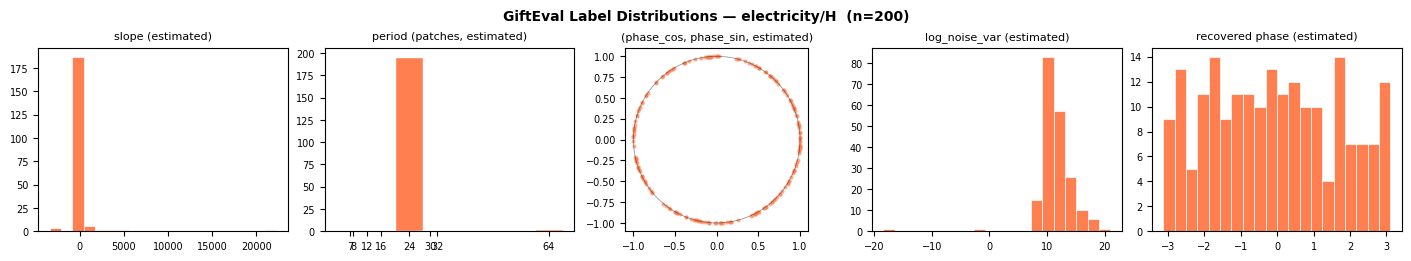

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.5), constrained_layout=True)
fig.suptitle(f'GiftEval Label Distributions — {GIFT_DATASET}  (n=200)', fontsize=10, fontweight='bold')

axes[0].hist(gift_data['slope'], bins=20, color='coral', edgecolor='white', lw=0.5)
axes[0].set_title('slope (estimated)')

counts = np.bincount(gift_data['period_idx'].astype(int), minlength=8)
axes[1].bar(PERIOD_BINS, counts, width=8, color='coral', edgecolor='white')
axes[1].set_title('period (patches, estimated)')
axes[1].set_xticks(PERIOD_BINS)

axes[2].scatter(gift_data['phase_cos'], gift_data['phase_sin'], s=4, alpha=0.5, color='coral')
theta = np.linspace(0, 2*np.pi, 200)
axes[2].plot(np.cos(theta), np.sin(theta), 'k-', lw=0.6, alpha=0.4)
axes[2].set_aspect('equal')
axes[2].set_title('(phase_cos, phase_sin, estimated)')

axes[3].hist(gift_data['log_noise_var'], bins=20, color='coral', edgecolor='white', lw=0.5)
axes[3].set_title('log_noise_var (estimated)')

phases = np.arctan2(gift_data['phase_sin'], gift_data['phase_cos'])
axes[4].hist(phases, bins=20, color='coral', edgecolor='white', lw=0.5)
axes[4].set_title('recovered phase (estimated)')

for ax in axes:
    ax.tick_params(labelsize=7)
plt.show()

---
## 4  Side-by-side: Synthetic vs GiftEval label distributions

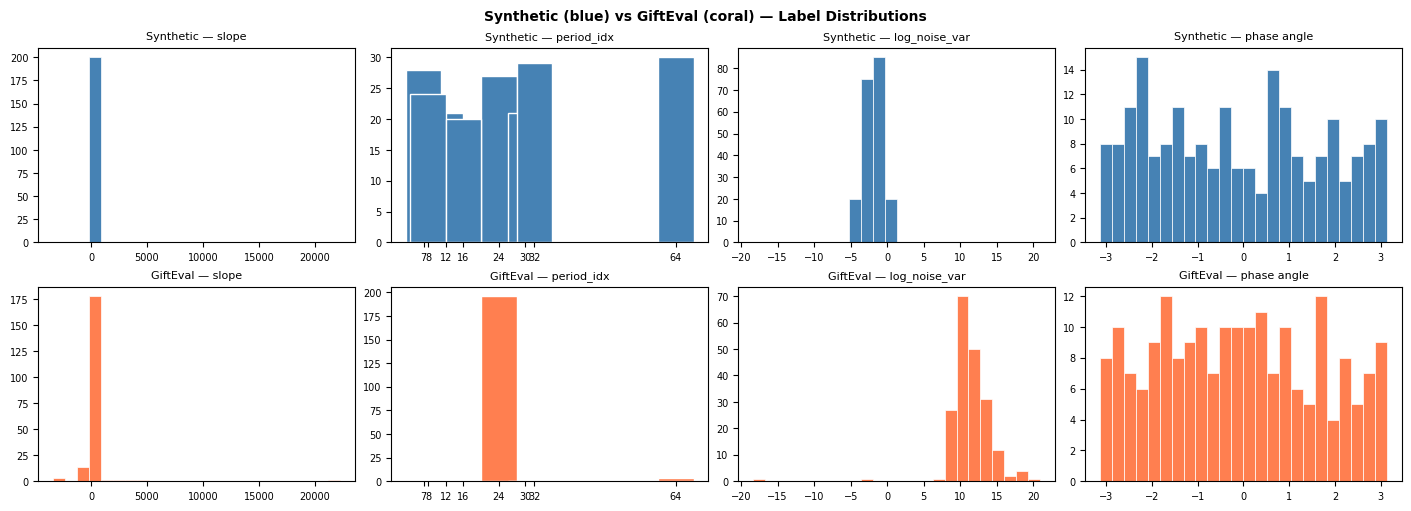

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Synthetic (blue) vs GiftEval (coral) — Label Distributions', fontsize=10, fontweight='bold')

for col, key in enumerate(['slope', 'period_idx', 'log_noise_var']):
    ax_s = axes[0, col]
    ax_g = axes[1, col]

    vals_s = synth[key].astype(float)
    vals_g = gift_data[key].astype(float)

    if key == 'period_idx':
        ax_s.bar(PERIOD_BINS, np.bincount(synth['period_idx'].astype(int), minlength=8),
                 width=8, color='steelblue', edgecolor='white')
        ax_g.bar(PERIOD_BINS, np.bincount(gift_data['period_idx'].astype(int), minlength=8),
                 width=8, color='coral', edgecolor='white')
        for ax in (ax_s, ax_g):
            ax.set_xticks(PERIOD_BINS)
    else:
        lo = min(vals_s.min(), vals_g.min())
        hi = max(vals_s.max(), vals_g.max())
        bins = np.linspace(lo, hi, 25)
        ax_s.hist(vals_s, bins=bins, color='steelblue', edgecolor='white', lw=0.5)
        ax_g.hist(vals_g, bins=bins, color='coral', edgecolor='white', lw=0.5)

    ax_s.set_title(f'Synthetic — {key}', fontsize=8)
    ax_g.set_title(f'GiftEval — {key}', fontsize=8)

# Phase angle column
phases_s = np.arctan2(synth['phase_sin'], synth['phase_cos'])
phases_g = np.arctan2(gift_data['phase_sin'], gift_data['phase_cos'])
bins_p = np.linspace(-np.pi, np.pi, 25)
axes[0, 3].hist(phases_s, bins=bins_p, color='steelblue', edgecolor='white', lw=0.5)
axes[0, 3].set_title('Synthetic — phase angle', fontsize=8)
axes[1, 3].hist(phases_g, bins=bins_p, color='coral', edgecolor='white', lw=0.5)
axes[1, 3].set_title('GiftEval — phase angle', fontsize=8)

for ax in axes.flat:
    ax.tick_params(labelsize=7)
plt.show()